# External Boosting and LSTM

## Goal
This notebook finishes the missing work for the advanced-modeling phase using **one split only: the time-aware split**.

Main tasks:
1. Build Feature Sets **A / B / C**
2. Run **XGBoost** sanity fit + early stopping + quick trial sweep
3. Train **LightGBM** and **CatBoost** baselines
4. Generate boosted-model diagnostics and worst-case tables
5. Build a **lag baseline**
6. Train a **tiny LSTM** on country-year sequences
7. Compare lag baseline vs LSTM

In [1]:
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

sys.path.append(str(PROJECT_ROOT / "src"))

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_LOG = TABLES_DIR / "week10_week11_runs.csv"

print("Project root:", PROJECT_ROOT)

Project root: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cffi

from sklearn.inspection import PartialDependenceDisplay

from modeling.baselines import ridge_cv
from modeling.pipelines import build_preprocessor, build_model_pipeline, infer_feature_types
from modeling.splits import make_time_split
from modeling.train_eval import train_eval
from data.feature_engineering import build_feature_sets_abc
from modeling.external_boosting import (
    get_xgb_trial_grid,
    run_external_timeaware_trial,
)
from modeling.sequence_models import (
    make_flat_lag_dataframe,
    build_country_sequences,
    run_tiny_lstm_timeaware,
)

sns.set_theme(style="whitegrid")

TARGET = "life_expectancy_final"
YEAR_COL = "year"
TEST_YEARS = 3

## Load processed dataset
This tries the two most likely processed dataset names used in the repo.

In [3]:
data_candidates = [
    PROJECT_ROOT / "data" / "processed" / "main_dataset.csv",
    PROJECT_ROOT / "data" / "processed" / "panel_dataset.csv",
]

DATA_PATH = None
for p in data_candidates:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find processed dataset. Expected one of:\n"
        + "\n".join(str(p) for p in data_candidates)
    )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print(df.shape)
df.head()

Loaded: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed/main_dataset.csv
(2265, 36)


,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,sanitation,injuries,communicable,noncommunicable_disease,life_expectancy_final
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,100,...,21.5,5949.999809,10.105348,3.25580,11.127,NaN,3673696.62,6528888.62,6988545.28,64.1885
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,100,...,20.7,4880.000114,9.528871,3.69522,11.142,NaN,3267937.78,6649335.87,6900348.40,61.4330
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,100,...,20.7,5989.999771,8.805941,3.45446,11.193,NaN,2807904.86,6813189.19,6799914.37,61.2125
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,100,...,21.1,8079.999924,7.897176,3.32000,11.341,NaN,2715550.23,7036448.02,6640268.93,60.7770
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,100,...,20.2,8930.000305,8.561907,3.46201,11.054,NaN,2540038.63,7181018.86,6539124.12,60.3765


## Build Feature Sets A / B / C
- **A** = full cleaned numeric set
- **B** = correlation-pruned
- **C** = more reduced, VIF-aware, manually interpretable set

In [4]:
model_df, feature_sets, feature_meta = build_feature_sets_abc(
    df,
    target_col=TARGET,
    year_col=YEAR_COL,
    corr_threshold=0.90,
    vif_threshold=10.0,
)

pd.DataFrame(
    {
        "feature_set": ["A", "B", "C"],
        "n_features": [
            len(feature_sets["A"]),
            len(feature_sets["B"]),
            len(feature_sets["C"]),
        ],
    }
)

/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encount

,feature_set,n_features
0,A,38
1,B,31
2,C,5


In [5]:
with open(TABLES_DIR / "week10_feature_sets.json", "w", encoding="utf-8") as f:
    json.dump(
        {"feature_sets": feature_sets, "meta": feature_meta},
        f,
        indent=2,
    )

## XGBoost sanity run
Start with one clean time-aware run on Feature Set B.

In [6]:
xgb_sanity_row, xgb_sanity_pred, xgb_sanity_model, xgb_sanity_prep = run_external_timeaware_trial(
    df=model_df,
    feature_list=feature_sets["B"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_family="xgb",
    model_name="XGB_sanity",
    test_years=TEST_YEARS,
    val_years=1,
    scale_mode="none",
    model_params={
        "n_estimators": 1200,
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_lambda": 1.0,
        "random_state": 42,
    },
    run_log_path=str(RUN_LOG),
)

pd.DataFrame([xgb_sanity_row])

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
0,XGB_sanity,time,1661,151,453,1.585589,1.154439,0.964125,1197


## XGBoost quick trial sweep
This is a minimal sweep that includes:
- early stopping,
- depth varied,
- learning rate varied,
- and capacity / subsampling varied.

In [7]:
xgb_trials = get_xgb_trial_grid(random_state=42)

xgb_rows = []
xgb_artifacts = {}

for trial in xgb_trials:
    row, pred_df, model, prep = run_external_timeaware_trial(
        df=model_df,
        feature_list=feature_sets["B"],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_family="xgb",
        model_name=trial["trial_name"],
        test_years=TEST_YEARS,
        val_years=1,
        scale_mode="none",
        model_params=trial["params"],
        run_log_path=str(RUN_LOG),
    )
    xgb_rows.append(row)
    xgb_artifacts[trial["trial_name"]] = {
        "pred_df": pred_df,
        "model": model,
        "prep": prep,
    }

xgb_results = pd.DataFrame(xgb_rows).sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])
xgb_results.to_csv(TABLES_DIR / "week10_xgb_trials.csv", index=False)
xgb_results

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
7,xgb_cap_1200_sub0.8_col0.8,time,1661,151,453,1.508539,1.114326,0.967527,1186
6,xgb_cap_800_sub0.8_col0.8,time,1661,151,453,1.513029,1.118291,0.967334,799
3,xgb_lr_0.03,time,1661,151,453,1.562566,1.155561,0.965160,1496
8,xgb_cap_1500_sub1.0_col0.8,time,1661,151,453,1.569049,1.165648,0.964870,1213
2,xgb_depth_7,time,1661,151,453,1.576439,1.146106,0.964538,1199
4,xgb_lr_0.05,time,1661,151,453,1.584212,1.153497,0.964188,1460
1,xgb_depth_5,time,1661,151,453,1.585589,1.154439,0.964125,1197
5,xgb_lr_0.1,time,1661,151,453,1.646231,1.187125,0.961329,1255
0,xgb_depth_3,time,1661,151,453,1.723869,1.272227,0.957595,1197


In [8]:
best_xgb_name = xgb_results.iloc[0]["model_name"]
best_xgb_name

'xgb_cap_1200_sub0.8_col0.8'

## Best XGBoost stability rerun
Re-run the best config with two seeds to check stability.

In [9]:
best_trial = next(t for t in xgb_trials if t["trial_name"] == best_xgb_name)

stability_rows = []
for seed in [42, 43]:
    params = dict(best_trial["params"])
    params["random_state"] = seed

    row, pred_df, model, prep = run_external_timeaware_trial(
        df=model_df,
        feature_list=feature_sets["B"],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_family="xgb",
        model_name=f"{best_xgb_name}_seed{seed}",
        test_years=TEST_YEARS,
        val_years=1,
        scale_mode="none",
        model_params=params,
        run_log_path=str(RUN_LOG),
    )
    stability_rows.append(row)

xgb_stability_df = pd.DataFrame(stability_rows)
xgb_stability_df.to_csv(TABLES_DIR / "week10_xgb_stability.csv", index=False)
xgb_stability_df

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
0,xgb_cap_1200_sub0.8_col0.8_seed42,time,1661,151,453,1.508539,1.114326,0.967527,1186
1,xgb_cap_1200_sub0.8_col0.8_seed43,time,1661,151,453,1.514054,1.131478,0.967289,1199


## LightGBM and CatBoost baselines
These are baseline external-boosting comparisons on the same time-aware split and Feature Set B.

In [10]:
lgbm_row, lgbm_pred, lgbm_model, lgbm_prep = run_external_timeaware_trial(
    df=model_df,
    feature_list=feature_sets["B"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_family="lgbm",
    model_name="LightGBM_baseline",
    test_years=TEST_YEARS,
    val_years=1,
    scale_mode="none",
    model_params={"random_state": 42},
    run_log_path=str(RUN_LOG),
)

cat_row, cat_pred, cat_model, cat_prep = run_external_timeaware_trial(
    df=model_df,
    feature_list=feature_sets["B"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_family="catboost",
    model_name="CatBoost_baseline",
    test_years=TEST_YEARS,
    val_years=1,
    scale_mode="none",
    model_params={"random_state": 42},
    run_log_path=str(RUN_LOG),
)

boost_compare = pd.DataFrame(
    [xgb_results.iloc[0].to_dict(), lgbm_row, cat_row]
).sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])

boost_compare.to_csv(TABLES_DIR / "week10_external_boosting_compare.csv", index=False)
boost_compare

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5097
[LightGBM] [Info] Number of data points in the train set: 1661, number of used features: 28
[LightGBM] [Info] Start training from score 68.526655


/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
0,xgb_cap_1200_sub0.8_col0.8,time,1661,151,453,1.508539,1.114326,0.967527,1186
1,LightGBM_baseline,time,1661,151,453,1.603425,1.165177,0.963314,728
2,CatBoost_baseline,time,1661,151,453,1.621755,1.185692,0.962470,1499


## Diagnostics for the best boosted model
These plots/tables give you:
- predicted vs actual
- residuals vs predicted
- residual histogram
- top 10 worst country-years
- MAE by region
- MAE by year

In [11]:
artifact_lookup = {
    best_xgb_name: xgb_artifacts[best_xgb_name]["pred_df"],
    "LightGBM_baseline": lgbm_pred,
    "CatBoost_baseline": cat_pred,
}

best_boost_model_name = boost_compare.iloc[0]["model_name"]
best_boost_pred = artifact_lookup[best_boost_model_name].copy()

worst10_boost = (
    best_boost_pred.sort_values("abs_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

mae_by_region_boost = (
    best_boost_pred.groupby("region", dropna=False)["abs_error"]
    .mean()
    .reset_index(name="mae")
    .sort_values("mae", ascending=False)
    .reset_index(drop=True)
    if "region" in best_boost_pred.columns
    else None
)

mae_by_year_boost = (
    best_boost_pred.groupby("year", dropna=False)["abs_error"]
    .mean()
    .reset_index(name="mae")
    .sort_values("year")
    .reset_index(drop=True)
)

worst10_boost.to_csv(TABLES_DIR / "week10_best_boost_worst10.csv", index=False)
mae_by_year_boost.to_csv(TABLES_DIR / "week10_best_boost_mae_by_year.csv", index=False)
if mae_by_region_boost is not None:
    mae_by_region_boost.to_csv(TABLES_DIR / "week10_best_boost_mae_by_region.csv", index=False)

display(worst10_boost)
display(mae_by_region_boost.head(10) if mae_by_region_boost is not None else "No region column")
display(mae_by_year_boost.head(10))

,y_true,y_pred,error,abs_error,year
0,51.970500,58.992218,7.021718,7.021718,2015
1,50.236000,56.158821,5.922821,5.922821,2014
2,65.049500,59.325718,-5.723782,5.723782,2013
3,52.865500,58.290939,5.425439,5.425439,2013
4,63.440500,58.518810,-4.921690,4.921690,2013
5,85.060976,80.207581,-4.853395,4.853395,2014
6,63.267000,59.005711,-4.261289,4.261289,2015
7,74.575500,78.753159,4.177659,4.177659,2015
8,72.070500,76.196060,4.125560,4.125560,2015
9,59.909500,64.034988,4.125488,4.125488,2015


'No region column'

,year,mae
0,2013,0.969396
1,2014,1.135126
2,2015,1.238456


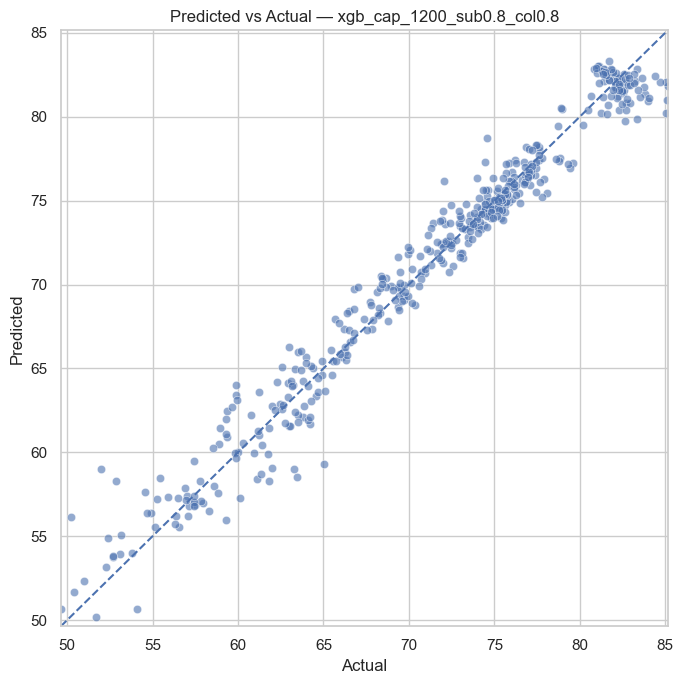

In [12]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_boost_pred, x="y_true", y="y_pred", alpha=0.6)
lims = [
    min(best_boost_pred["y_true"].min(), best_boost_pred["y_pred"].min()),
    max(best_boost_pred["y_true"].max(), best_boost_pred["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual — {best_boost_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week10_best_boost_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

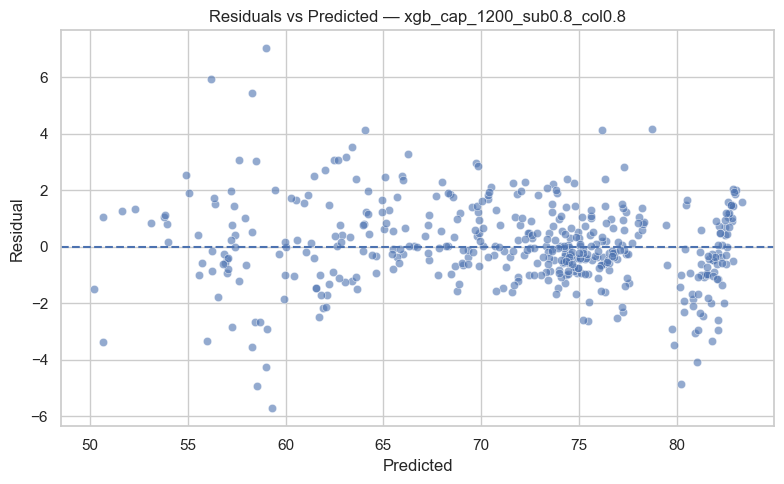

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=best_boost_pred, x="y_pred", y="error", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predicted — {best_boost_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week10_best_boost_residual_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()

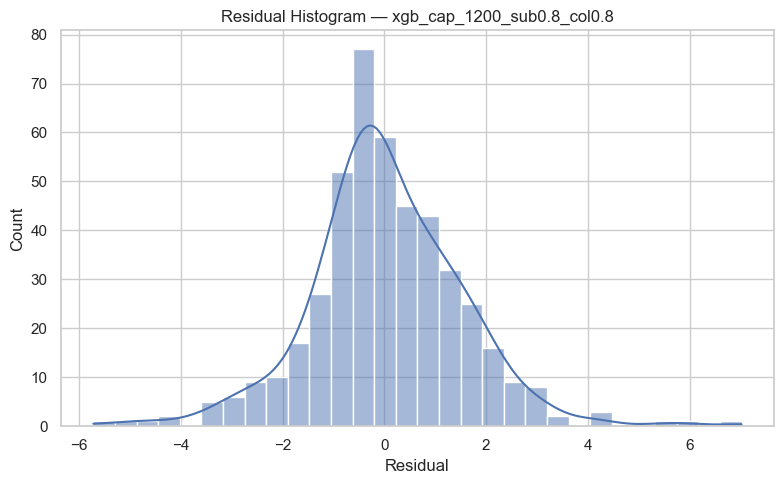

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(best_boost_pred["error"], bins=30, kde=True)
plt.xlabel("Residual")
plt.title(f"Residual Histogram — {best_boost_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week10_best_boost_residual_hist.png", dpi=200, bbox_inches="tight")
plt.show()

## Lag baseline
This is the simpler temporal baseline: previous country-year target and key features are turned into lagged tabular predictors.

In [15]:
# create status_flag if missing
if "status_flag" not in df.columns and "status" in df.columns:
    df = df.copy()
    df["status_flag"] = (
        df["status"].astype(str).str.lower().str.contains("developed")
    ).astype(int)
    
country_cols = [c for c in ["country", "country_code", "region", "income_group"] if c in df.columns]
lag_source_cols = country_cols + [YEAR_COL, TARGET] + [c for c in feature_sets["C"] if c != YEAR_COL and c != TARGET]
lag_source_df = df[lag_source_cols].copy()

lag_df = make_flat_lag_dataframe(
    lag_source_df,
    feature_cols=[c for c in feature_sets["C"] if c != YEAR_COL and c != TARGET],
    target_col=TARGET,
    country_col="country",
    year_col=YEAR_COL,
    lags=(1, 2, 3),
)

lag_feature_cols = [c for c in lag_df.columns if c not in country_cols + [YEAR_COL, TARGET]]
len(lag_feature_cols), lag_df.shape

(19, (1812, 25))

In [16]:
from modeling.splits import make_time_split
from modeling.train_eval import train_eval
from modeling.pipelines import build_preprocessor, build_model_pipeline, infer_feature_types
from modeling.baselines import ridge_cv

X_train, X_test, y_train, y_test, lag_split_info = make_time_split(
    lag_df,
    target_col=TARGET,
    year_col=YEAR_COL,
    test_years=TEST_YEARS,
)

Xtr = X_train[lag_feature_cols].copy()
Xte = X_test[lag_feature_cols].copy()

num_cols, cat_cols = infer_feature_types(Xtr)
prep = build_preprocessor(num_cols, cat_cols, scale_numeric=True)
lag_pipe = build_model_pipeline(ridge_cv(), prep)

lag_result, lag_pred = train_eval(
    lag_pipe,
    Xtr,
    y_train,
    Xte,
    y_test,
    model_name="LagRidgeCV",
    split_name="time_lagged",
    return_predictions_df=True,
    id_df=lag_df[[c for c in country_cols + [YEAR_COL] if c in lag_df.columns]],
    id_cols=[c for c in country_cols + [YEAR_COL] if c in lag_df.columns],
)

lag_row = lag_result.__dict__
pd.DataFrame([lag_row])

,model_name,split_name,n_train,n_test,rmse,mae,r2
0,LagRidgeCV,time_lagged,1359,453,0.870962,0.453579,0.989176


## LSTM
Main sequence model: country histories are turned into sliding windows and the model predicts next-year life expectancy.

In [17]:
sequence_feature_cols = [c for c in feature_sets["C"] if c != YEAR_COL and c != TARGET]
sequence_source_cols = country_cols + [YEAR_COL, TARGET] + sequence_feature_cols
sequence_source_df = df[sequence_source_cols].copy()

X_seq, y_seq, meta_seq, seq_cols = build_country_sequences(
    sequence_source_df,
    feature_cols=sequence_feature_cols,
    target_col=TARGET,
    country_col="country",
    year_col=YEAR_COL,
    window=3,
    include_target_history=True,
)

X_seq.shape, len(seq_cols)

((1812, 3, 5), 5)

In [18]:
import torch
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

lstm_row, lstm_pred, lstm_model, lstm_scaler, lstm_split = run_tiny_lstm_timeaware(
    X_seq,
    y_seq,
    meta_seq,
    year_col=YEAR_COL,
    test_years=TEST_YEARS,
    val_years=1,
    hidden_size=32,
    num_layers=1,
    learning_rate=1e-3,
    batch_size=64,
    epochs=25,
    patience=5,
    random_state=42,
)

pd.DataFrame([lstm_row])

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_epoch
0,TinyLSTM_delta,time_sequence,1208,151,453,1.352221,0.857426,0.973908,23


## Lag baseline vs LSTM

In [19]:
lag_vs_lstm = pd.DataFrame([lag_row, lstm_row]).sort_values(
    ["rmse", "mae", "r2"],
    ascending=[True, True, False],
)

lag_vs_lstm.to_csv(TABLES_DIR / "week11_lag_vs_lstm.csv", index=False)
lag_vs_lstm

,model_name,split_name,n_train,n_test,rmse,mae,r2,n_val,best_epoch
0,LagRidgeCV,time_lagged,1359,453,0.870962,0.453579,0.989176,NaN,NaN
1,TinyLSTM_delta,time_sequence,1208,453,1.352221,0.857426,0.973908,151.0,23.0


In [20]:
best_temporal_pred = lag_pred.copy() if lag_row["rmse"] <= lstm_row["rmse"] else lstm_pred.copy()
best_temporal_name = "LagRidgeCV" if lag_row["rmse"] <= lstm_row["rmse"] else "TinyLSTM"

worst10_temporal = (
    best_temporal_pred.sort_values("abs_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

mae_by_year_temporal = (
    best_temporal_pred.groupby("year", dropna=False)["abs_error"]
    .mean()
    .reset_index(name="mae")
    .sort_values("year")
    .reset_index(drop=True)
)

worst10_temporal.to_csv(TABLES_DIR / "week11_best_temporal_worst10.csv", index=False)
mae_by_year_temporal.to_csv(TABLES_DIR / "week11_best_temporal_mae_by_year.csv", index=False)

display(worst10_temporal)
display(mae_by_year_temporal.head(10))

,y_true,y_pred,error,abs_error,country,country_code,region,income_group,year
0,65.049500,60.828084,-4.221416,4.221416,South Africa,ZAF,Sub-Saharan Africa,Upper middle income,2013
1,63.267000,59.157179,-4.109821,4.109821,Zimbabwe,ZWE,Sub-Saharan Africa,Lower middle income,2015
2,80.820732,84.506259,3.685527,3.685527,Germany,DEU,Europe & Central Asia,High income,2015
3,81.118293,84.747559,3.629266,3.629266,Austria,AUT,Europe & Central Asia,High income,2013
4,81.290244,84.820936,3.530693,3.530693,Finland,FIN,Europe & Central Asia,High income,2015
5,69.468500,72.898370,3.429870,3.429870,Iraq,IRQ,Middle East & North Africa,Upper middle income,2013
6,81.046341,84.404322,3.357981,3.357981,Belgium,BEL,Europe & Central Asia,High income,2015
7,64.227500,60.880304,-3.347196,3.347196,Niger,NER,Sub-Saharan Africa,Low income,2013
8,81.112195,84.395349,3.283154,3.283154,Portugal,PRT,Europe & Central Asia,High income,2015
9,81.018293,84.231925,3.213633,3.213633,Greece,GRC,Europe & Central Asia,High income,2015


,year,mae
0,2013,0.515234
1,2014,0.420848
2,2015,0.424655


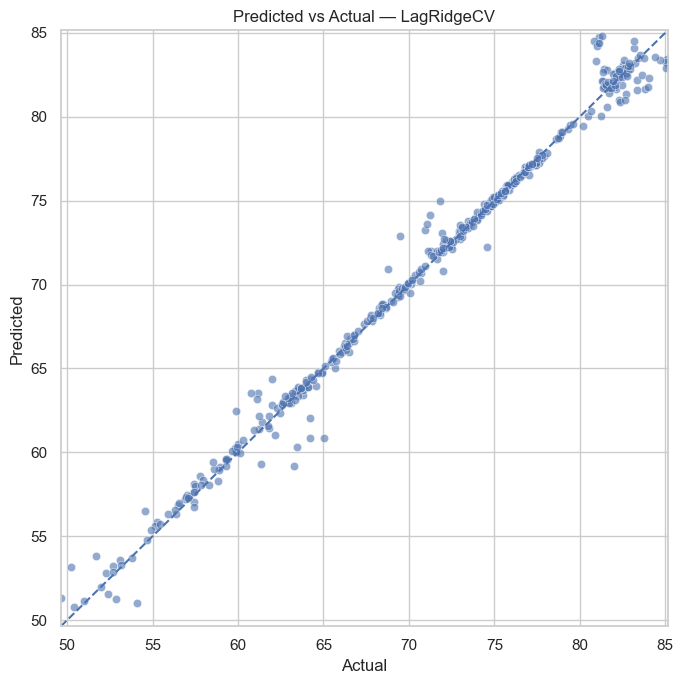

In [21]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_temporal_pred, x="y_true", y="y_pred", alpha=0.6)
lims = [
    min(best_temporal_pred["y_true"].min(), best_temporal_pred["y_pred"].min()),
    max(best_temporal_pred["y_true"].max(), best_temporal_pred["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual — {best_temporal_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week11_best_temporal_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

## LSTM tuning
Run two small LSTM variants to check whether the poor initial result is due to architecture choice or whether the sequence model is simply not competitive in this low-signal, small-window setting.

In [22]:
variants = [
    {"window": 3, "hidden_size": 32},
    {"window": 5, "hidden_size": 64},
]

rows = []
preds = {}

for v in variants:
    X_seq, y_seq, meta_seq, seq_cols = build_country_sequences(
        sequence_source_df,
        feature_cols=sequence_feature_cols,
        target_col=TARGET,
        country_col="country",
        year_col=YEAR_COL,
        window=v["window"],
        include_target_history=True,
    )

    row, pred_df, model, scaler, split_dict = run_tiny_lstm_timeaware(
        X_seq, y_seq, meta_seq,
        year_col=YEAR_COL,
        test_years=TEST_YEARS,
        val_years=1,
        hidden_size=v["hidden_size"],
        num_layers=1,
        learning_rate=5e-4,
        batch_size=128,
        epochs=60,
        patience=8,
        predict_delta=True,
        torch_threads=1,
    )

    row["variant"] = f"delta_w{v['window']}_h{v['hidden_size']}"
    row["window"] = v["window"]
    row["hidden_size"] = v["hidden_size"]
    rows.append(row)
    preds[row["variant"]] = pred_df

lstm_compare = pd.DataFrame(rows).sort_values("rmse")
lstm_compare

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_epoch,variant,window,hidden_size
1,TinyLSTM_delta,time_sequence,906,151,453,1.075997,0.726779,0.983479,60,delta_w5_h64,5,64
0,TinyLSTM_delta,time_sequence,1208,151,453,1.303697,0.870987,0.975747,59,delta_w3_h32,3,32


## WDI reduced-feature test
This section evaluates how much predictive performance is retained when moving to a WDI-style reduced dataset with fewer available features. Because the current WDI export is organized as indicator-by-year and, in the current file, the immediately available aligned signal is life expectancy itself, this test is framed as a reduced-feature temporal forecasting benchmark rather than a full replacement of the merged WHO + World Bank panel.

In [23]:
from data.data_loading import load_raw, standardize


WDI_PATH = PROJECT_ROOT / "data" / "raw" / "world_bank" / "wdi.csv" 

wdi_path = Path("../data/raw/world_bank/wdi.csv")  
wdi_raw = load_raw("wdi", path=wdi_path)
wdi = standardize(wdi_raw, "wdi")

year_cols = [c for c in wdi.columns if str(c).isdigit()]

wdi_long = wdi.melt(
    id_vars=["country", "country_code", "indicator_name", "indicator_code"],
    value_vars=year_cols,
    var_name="year",
    value_name="value",
)
wdi_long["year"] = pd.to_numeric(wdi_long["year"], errors="coerce").astype("Int64")
wdi_long["value"] = pd.to_numeric(wdi_long["value"], errors="coerce")
wdi_long = wdi_long.dropna(subset=["country", "year", "value"]).copy()
wdi_long["year"] = wdi_long["year"].astype(int)

wdi_long.head()

,country,country_code,indicator_name,indicator_code,year,value
0,Aruba,ABW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,64.049000
1,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,44.169658
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,32.799000
3,Africa Western and Central,AFW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,37.779636
4,Angola,AGO,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,37.933000


In [24]:
# choose WDI indicators 
wanted_codes = [
    "SP.DYN.LE00.IN",  # life expectancy
]

wdi_sel = wdi_long[wdi_long["indicator_code"].isin(wanted_codes)].copy()

wdi_panel = (
    wdi_sel.pivot_table(
        index=["country", "country_code", "year"],
        columns="indicator_code",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
)

wdi_panel.columns.name = None
wdi_panel.head()

,country,country_code,year,SP.DYN.LE00.IN
0,Afghanistan,AFG,1960,32.799
1,Afghanistan,AFG,1961,33.291
2,Afghanistan,AFG,1962,33.757
3,Afghanistan,AFG,1963,34.201
4,Afghanistan,AFG,1964,34.673


In [25]:
TARGET_WDI = "SP.DYN.LE00.IN"  # WDI life expectancy series

train_year_min = int(pd.to_numeric(df["year"], errors="raise").min())
train_year_max = int(pd.to_numeric(df["year"], errors="raise").max())

# years trained on in main dataset 
train_year_min, train_year_max

(2001, 2015)

### Past and Future Split

In [26]:
wdi_past = wdi_panel[wdi_panel["year"] < train_year_min].copy()
wdi_train_years = wdi_panel[(wdi_panel["year"] >= train_year_min) & (wdi_panel["year"] <= train_year_max)].copy()
wdi_future = wdi_panel[wdi_panel["year"] > train_year_max].copy()

print("WDI past years:", wdi_past["year"].min(), "-", wdi_past["year"].max(), "rows:", len(wdi_past))
print("WDI train-range years:", wdi_train_years["year"].min(), "-", wdi_train_years["year"].max(), "rows:", len(wdi_train_years))
print("WDI future years:", wdi_future["year"].min(), "-", wdi_future["year"].max(), "rows:", len(wdi_future))

WDI past years: 1960 - 2000 rows: 10831
WDI train-range years: 2001 - 2015 rows: 3975
WDI future years: 2016 - 2023 rows: 2120


### Build WDI lag dataset

In [28]:
wdi_full = wdi_panel.sort_values(["country","year"]).copy()

for lag in [1,2,3]:
    wdi_full[f"{TARGET_WDI}_lag{lag}"] = wdi_full.groupby("country")[TARGET_WDI].shift(lag)

# Keep rows where lag exists 
wdi_full_lagged = wdi_full.dropna(subset=[f"{TARGET_WDI}_lag1", f"{TARGET_WDI}_lag2", f"{TARGET_WDI}_lag3", TARGET_WDI]).copy()

lag_features = ["year", f"{TARGET_WDI}_lag1", f"{TARGET_WDI}_lag2", f"{TARGET_WDI}_lag3"]

In [29]:
train_mask = (wdi_full_lagged["year"] >= train_year_min) & (wdi_full_lagged["year"] <= train_year_max)
past_mask  = (wdi_full_lagged["year"] < train_year_min)
fut_mask   = (wdi_full_lagged["year"] > train_year_max)

train_df = wdi_full_lagged[train_mask].copy()
past_df  = wdi_full_lagged[past_mask].copy()
fut_df   = wdi_full_lagged[fut_mask].copy()

Xtr, ytr = train_df[lag_features], train_df[TARGET_WDI]
Xp,  yp  = past_df[lag_features],  past_df[TARGET_WDI]
Xf,  yf  = fut_df[lag_features],   fut_df[TARGET_WDI]

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor

In [31]:
def reg_metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

def eval_on_split(model, X, y):
    pred = model.predict(X)
    m = reg_metrics(y, pred)
    return m, pred

### Train all models on WDI

In [32]:
# Pipelines
ridge_wdi = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ridge_cv()),
])

hgbr_wdi = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_leaf_nodes=31,
        max_iter=600,
        random_state=42,
    )),
])

rf_wdi = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

et_wdi = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

models = {
    "WDI_RidgeLag": ridge_wdi,
    "WDI_HistGBR_Lag": hgbr_wdi,
    "WDI_RandomForest_Lag": rf_wdi,
    "WDI_ExtraTrees_Lag": et_wdi,
}

# Optional XGBoost if installed
try:
    from xgboost import XGBRegressor
    xgb_wdi = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            tree_method="hist",
        ))
    ])
    models["WDI_XGB_Lag"] = xgb_wdi
except Exception as e:
    print("XGBoost not available (skipping):", e)

In [33]:
# Fit on 2000–2015 only
for name, mdl in models.items():
    mdl.fit(Xtr, ytr)

rows = []
pred_store = {}  # keep preds for plotting

for name, mdl in models.items():
    past_m, past_pred = eval_on_split(mdl, Xp, yp)
    fut_m,  fut_pred  = eval_on_split(mdl, Xf, yf)

    rows.append({"model": name, "split": "past_unseen",  **past_m})
    rows.append({"model": name, "split": "future_unseen", **fut_m})

    pred_store[(name, "past_unseen")] = past_pred
    pred_store[(name, "future_unseen")] = fut_pred

wdi_compare = pd.DataFrame(rows).sort_values(["split", "rmse"])
wdi_compare

,model,split,rmse,mae,r2
7,WDI_ExtraTrees_Lag,future_unseen,1.382133,0.638976,0.966782
5,WDI_RandomForest_Lag,future_unseen,1.430367,0.663615,0.964423
3,WDI_HistGBR_Lag,future_unseen,1.450634,0.684903,0.963408
1,WDI_RidgeLag,future_unseen,1.460237,0.676893,0.962922
9,WDI_XGB_Lag,future_unseen,1.491243,0.678731,0.961330
0,WDI_RidgeLag,past_unseen,1.303671,0.517310,0.985302
4,WDI_RandomForest_Lag,past_unseen,2.082546,0.675580,0.962492
6,WDI_ExtraTrees_Lag,past_unseen,2.101130,0.663085,0.961820
8,WDI_XGB_Lag,past_unseen,2.219483,0.773930,0.957397
2,WDI_HistGBR_Lag,past_unseen,2.289640,0.825604,0.954662


In [34]:
wdi_compare.to_csv(TABLES_DIR / "week11_wdi_models_past_future_compare.csv", index=False)

### Save predictions

In [35]:
def make_pred_df(base_df, y_true, y_pred):
    out = base_df[["country", "country_code", "year"]].copy()
    out["y_true"] = np.asarray(y_true)
    out["y_pred"] = np.asarray(y_pred)
    out["error"] = out["y_pred"] - out["y_true"]
    out["abs_error"] = np.abs(out["error"])
    return out

for name in models.keys():
    past_pred_df = make_pred_df(past_df, yp, pred_store[(name, "past_unseen")])
    fut_pred_df  = make_pred_df(fut_df,  yf, pred_store[(name, "future_unseen")])

    past_pred_df.to_csv(TABLES_DIR / f"week11_{name}_wdi_past_preds.csv", index=False)
    fut_pred_df.to_csv(TABLES_DIR / f"week11_{name}_wdi_future_preds.csv", index=False)

### Bar chart: RMSE by model for past vs future

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

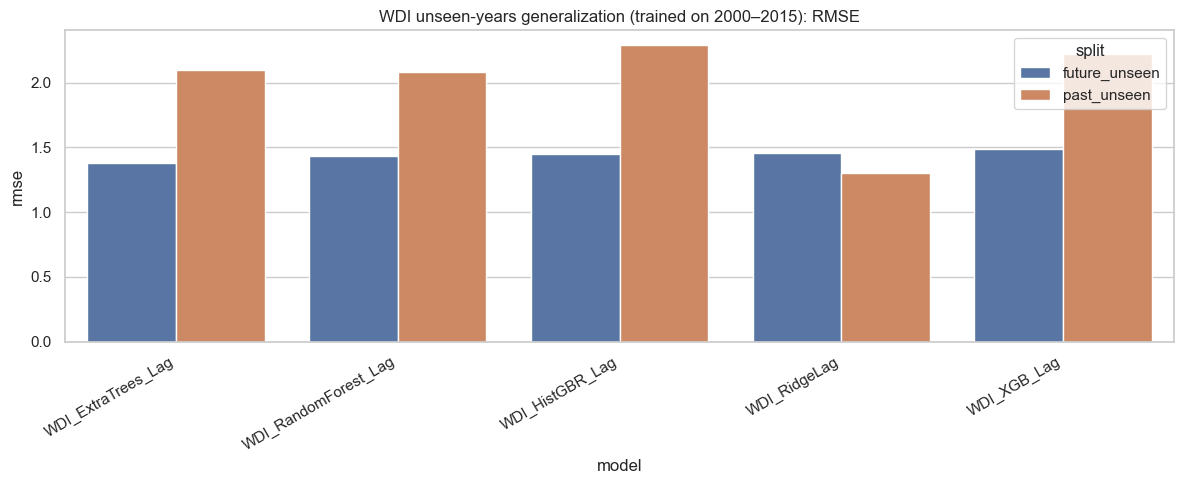

In [37]:
plt.figure(figsize=(12, 5))
sns.barplot(data=wdi_compare, x="model", y="rmse", hue="split")
plt.xticks(rotation=30, ha="right")
plt.title("WDI unseen-years generalization (trained on 2000–2015): RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week11_wdi_past_vs_future_rmse_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

### Predicted vs Actual for the best model (future unseen)

In [38]:
best_future_model = (
    wdi_compare[wdi_compare["split"] == "future_unseen"]
    .sort_values("rmse")
    .iloc[0]["model"]
)
best_future_model

'WDI_ExtraTrees_Lag'

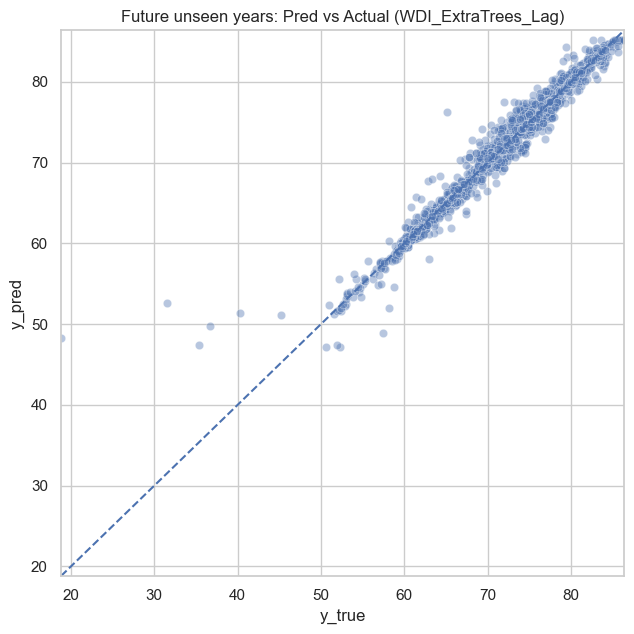

In [39]:
best_future_pred_df = pd.read_csv(TABLES_DIR / f"week11_{best_future_model}_wdi_future_preds.csv")

plt.figure(figsize=(6.5, 6.5))
sns.scatterplot(data=best_future_pred_df, x="y_true", y="y_pred", alpha=0.4)
lims = [min(best_future_pred_df["y_true"].min(), best_future_pred_df["y_pred"].min()),
        max(best_future_pred_df["y_true"].max(), best_future_pred_df["y_pred"].max())]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims); plt.ylim(lims)
plt.title(f"Future unseen years: Pred vs Actual ({best_future_model})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"week11_wdi_future_pred_vs_actual_{best_future_model}.png", dpi=200, bbox_inches="tight")
plt.show()

### Residual histogram for best model (future unseen)

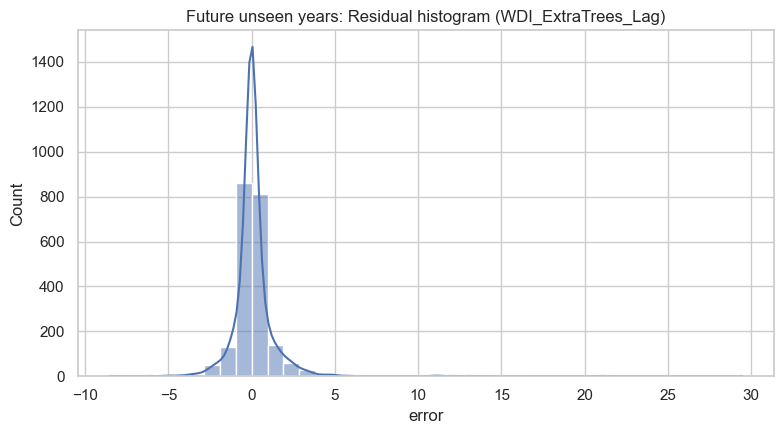

In [40]:
plt.figure(figsize=(8, 4.5))
sns.histplot(best_future_pred_df["error"], bins=40, kde=True)
plt.title(f"Future unseen years: Residual histogram ({best_future_model})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"week11_wdi_future_residual_hist_{best_future_model}.png", dpi=200, bbox_inches="tight")
plt.show()

### Error by year line plot (future unseen)

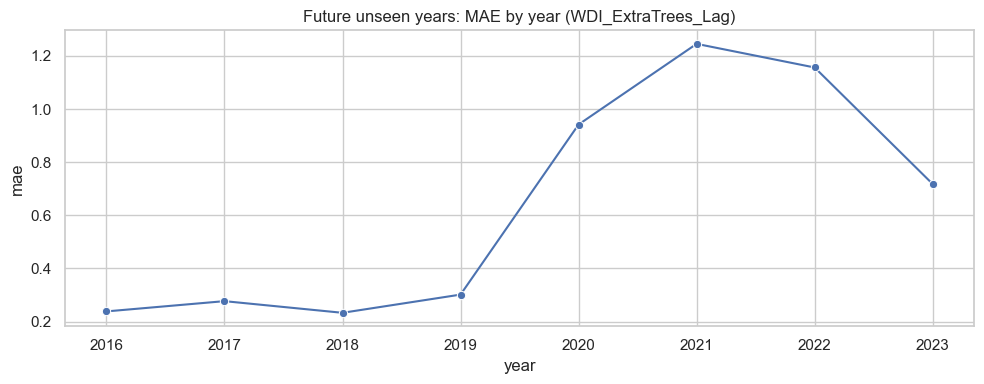

In [41]:
mae_by_year = (
    best_future_pred_df.groupby("year", dropna=False)["abs_error"]
    .mean()
    .reset_index(name="mae")
    .sort_values("year")
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=mae_by_year, x="year", y="mae", marker="o")
plt.title(f"Future unseen years: MAE by year ({best_future_model})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"week11_wdi_future_mae_by_year_{best_future_model}.png", dpi=200, bbox_inches="tight")
plt.show()

### “Error by country” ranked plot (future unseen)

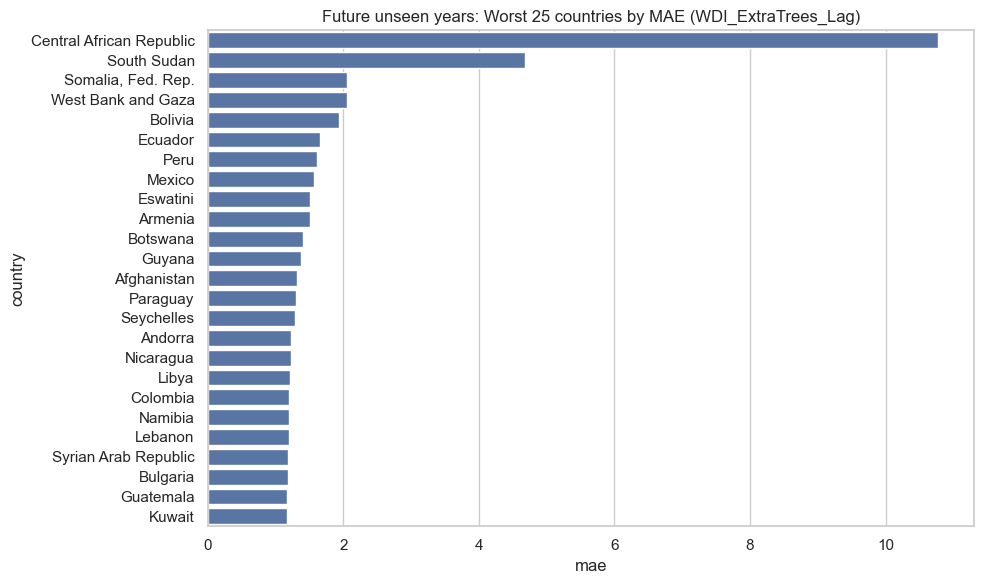

In [42]:
mae_by_country = (
    best_future_pred_df.groupby("country", dropna=False)["abs_error"]
    .mean()
    .reset_index(name="mae")
    .sort_values("mae", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=mae_by_country, x="mae", y="country")
plt.title(f"Future unseen years: Worst 25 countries by MAE ({best_future_model})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"week11_wdi_future_worst_countries_{best_future_model}.png", dpi=200, bbox_inches="tight")
plt.show()